## Importation des bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## Importation de la base de données

In [2]:
# Récupération des données via l'url accessible sur : https://www.data.gouv.fr/datasets/recensement-des-equipements-sportifs-espaces-et-sites-de-pratiques
# Chargement long

# data = pd.read_csv("https://www.data.gouv.fr/api/1/datasets/r/ea4f5879-af40-4e3e-949d-812d6eeb5e02")

# Récupération directement depuis le dernier csv téléchargé au préalable et stocké sur le s3

data = pd.read_csv("https://minio.lab.sspcloud.fr/matteo/data-es.csv", sep=";")
data.head(10)

/tmp/ipykernel_151085/2388994187.py:8: DtypeWarning: Columns (6,8,19,23,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("https://minio.lab.sspcloud.fr/matteo/data-es.csv", sep=";")


,equip_numero,inst_numero,inst_enqu_date,inst_nom,inst_siret,inst_adresse,inst_cp,new_name,new_code,inst_part_type_filter,...,equip_pshs_trib,equip_pshs_vest,equip_x,equip_y,inst_part_type,aps_name,equip_qpv,equip_qpv_200m,categorie,gen_2024fin_labellisation
0,E001I690130008,I690130008,2025-03-31,"Complexe sportif ""espace grange moulin""",2.169001e+13,2500 route de longsard,69400,Arnas,69013,Complexe sportif,...,False,False,4.699920,46.027570,"[""Complexe sportif""]","Activités de forme et de santé,Judo / Jujitsu ...",NaN,NaN,structurant,NaN
1,E005I352970009,I352970009,2025-03-31,Complexe sportif extérieur,2.135030e+13,Rue du Stade,35290,Saint-Méen-le-Grand,35297,Complexe sportif,...,False,False,-2.195597,48.187456,"[""Complexe sportif""]",Tennis,NaN,NaN,NaN,NaN
2,E003I973090057,I973090057,2025-03-31,Sporty training 54,9.833028e+13,3 rue Eugène PAJO,97354,Remire-Montjoly,97309,NaN,...,False,False,-52.276054,4.889464,NaN,"Activités de forme et de santé,Football / Foot...",NaN,NaN,proximité,NaN
3,E001I690130009,I690130009,2025-03-31,Nutrifit'Studio,NaN,71 Rue de Prairie,69400,Arnas,69013,NaN,...,False,False,4.726686,46.009865,NaN,Autres Danses,NaN,NaN,NaN,NaN
4,E005I353000003,I353000003,2025-03-31,Base de loisirs de la Haute-Vilaine,2.000390e+13,La petite ville cuite,35500,Saint-M'Hervé,35300,NaN,...,False,False,-1.119803,48.150394,NaN,Vtt (Cross Country/ Descente/ Trial/ Rallye/ F...,NaN,NaN,proximité,NaN
5,E001I690130010,I690130010,2025-03-31,Complexe de l'Escale,2.000406e+13,2726 route de Longsard,69400,Arnas,69013,NaN,...,False,False,4.697937,46.029623,NaN,"Badminton,Jeu de volant,Basket-Ball,Handball /...",NaN,NaN,structurant,NaN
6,E005I353080002,I353080002,2025-03-31,Complexe sportif,NaN,Rue de l'Egalité,35720,Mesnil-Roc'h,35308,Complexe sportif,...,False,False,-1.906630,48.444570,"[""Complexe sportif""]","Judo-jujitsu,kendo et disciplines associees (A...",NaN,NaN,NaN,NaN
7,E001I690140003,I690140003,2025-03-31,TYROLIENNE,2.169001e+13,NaN,69610,Aveize,69014,NaN,...,False,False,4.477480,45.680390,NaN,Escalade sur PAH,NaN,NaN,NaN,NaN
8,E005I353120002,I353120002,2025-03-31,Les circuits de randonnées,2.135031e+13,rue des bateliers,35580,Saint-Senoux,35312,NaN,...,False,False,-1.789120,47.905700,NaN,"Randonnée pédestre,Vtt (Cross Country/ Descent...",NaN,NaN,NaN,NaN
9,E001I690150002,I690150002,2025-03-31,PARCOURS D'AVENTURE DU HAUT BEAUJOLAIS,2.000844e+13,sentier du pardon,69430,Deux-Grosnes,69135,NaN,...,False,False,4.594710,46.193230,NaN,Escalade dans les arbres,NaN,NaN,NaN,NaN


## ACP sur la BDD complète

### Normalisation pour éviter que des départements prennent toute l'explication

In [3]:
table_dep =(
    data
    .groupby(['dep_nom', 'equip_type_famille'])
    .size()
    .unstack(fill_value=0)
)

table_dep.head()


scaler = StandardScaler()
table_norm = scaler.fit_transform(table_dep)
table_norm = table_dep.div(table_dep.sum(axis=1), axis=0)

### Création de l'ACP

In [4]:
pca = PCA(n_components=2)
coords = pca.fit_transform(table_norm)

# Dataframe des résultats
df_pca = pd.DataFrame(coords, columns=['PC1', 'PC2'])
df_pca['dep_nom'] = table_dep.index

### Visualisation en deux dimensions

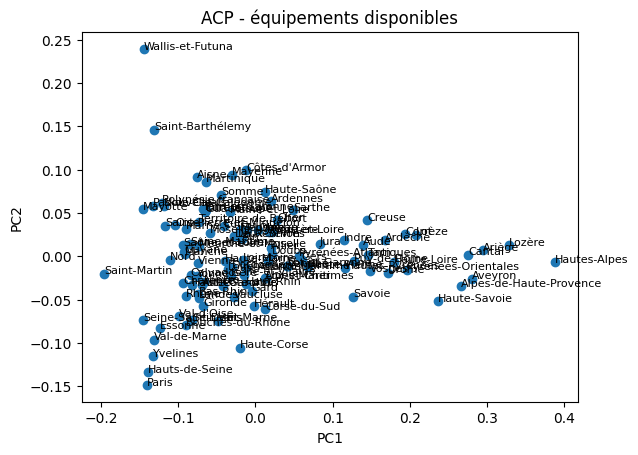

In [5]:
plt.figure()
plt.scatter(df_pca['PC1'], df_pca['PC2'])

for i, dep in enumerate(df_pca['dep_nom']):
    plt.text(df_pca['PC1'][i], df_pca['PC2'][i], dep, fontsize=8)

plt.title("ACP - équipements disponibles")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### Création de 5 clusteurs avec l'algorithme des kmeans

In [6]:
kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(table_norm)

table_dep['cluster'] = clusters
df_pca['cluster'] = clusters

In [7]:
cluster_profile = table_dep.groupby('cluster').mean()
cluster_profile

equip_type_famille,Aire de sports de glaces,Bassin de natation,Boulodrome,Bowling,Circuit/piste de sports mécaniques,Court de tennis,Divers équipements,Divers équipements Sports de nature,Equipement & piste de ski,Equipement d'activités de forme et de santé,...,Salle multisports,Salle non spécialisée,Salle ou terrain spécialisé,Site d'activités aquatiques et nautiques,Site d'activités aériennes,Site de modélisme,Skatepark & vélo Freestyle,Structure Artificielle d'Escalade,Terrain de grands jeux,Terrain extérieur de petits jeux collectifs
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.375000,60.531250,317.062500,2.593750,16.125000,365.437500,3.906250,288.765625,3.250000,123.187500,...,186.375000,168.140625,143.718750,114.109375,18.734375,6.609375,36.234375,27.390625,457.203125,145.843750
1,3.333333,50.333333,164.000000,2.000000,11.777778,229.555556,1.000000,1036.111111,27.777778,64.333333,...,68.222222,90.333333,66.666667,116.444444,58.666667,4.000000,26.555556,24.777778,180.555556,63.333333
2,0.000000,9.750000,30.000000,0.000000,2.500000,49.500000,0.000000,21.250000,0.000000,19.250000,...,29.000000,17.000000,21.750000,65.000000,6.000000,0.000000,3.750000,4.750000,105.000000,50.750000
3,1.947368,54.105263,235.105263,2.894737,17.052632,271.052632,2.473684,672.315789,12.684211,92.210526,...,123.894737,126.842105,100.052632,125.842105,33.000000,4.473684,28.315789,23.947368,323.684211,115.947368
4,2.545455,102.454545,207.272727,5.363636,8.727273,703.909091,3.363636,129.181818,0.090909,277.818182,...,324.545455,190.181818,318.090909,53.181818,11.636364,6.000000,47.272727,57.545455,380.636364,202.363636


### Visualisation des clusteurs

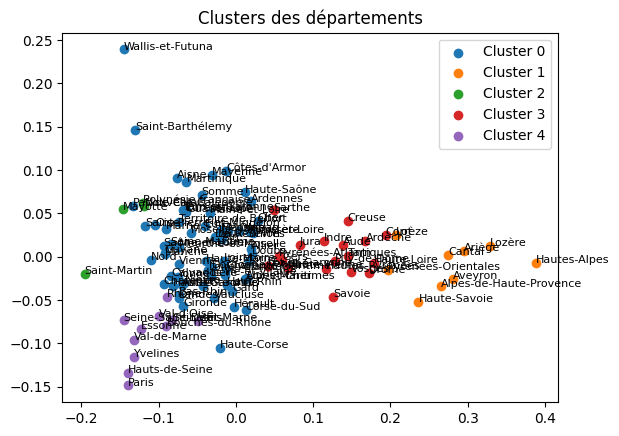

In [8]:
plt.figure()

for c in range(5):
    subset = df_pca[df_pca['cluster'] == c]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {c}')

    for i, dep in enumerate(subset['dep_nom']):
        plt.text(subset['PC1'].iloc[i], subset['PC2'].iloc[i], dep, fontsize=8)

plt.legend()
plt.title("Clusters des départements")
plt.show()